# Classificação de alfabetização

Notebook para prever `alfabetizado` usando o arquivo `data/sample/df_alunos_sample.parquet`. A separação respeita o tempo: 2023 é dividido em treino e validação; 2024 é reservado integralmente para teste.

> **Importante:** `proficiencia` e indicadores contemporâneos de alfabetização são excluídos por padrão, pois podem refletir a própria medição que gera o alvo. Revise a lista de leakage com a área de negócio antes de colocar o modelo em produção.

In [16]:
from pathlib import Path
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    recall_score,
    precision_score,
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    auc
)

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_STATE = 42
TARGET = 'alfabetizado'
PROJECT_DIR = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_PATH = PROJECT_DIR / 'data' / 'sample' / 'df_alunos_sample.parquet'
assert DATA_PATH.exists(), f'Arquivo não encontrado: {DATA_PATH.resolve()}'

df = pd.read_parquet(DATA_PATH)
df.shape, df['ano'].value_counts().sort_index(), df[TARGET].value_counts(normalize=True)

((386816, 48),
 ano
 2023    174743
 2024    212073
 Name: count, dtype: int64,
 alfabetizado
 1    0.51305
 0    0.48695
 Name: proportion, dtype: float64)

## 1. Higienização: constantes e leakage

A função abaixo remove automaticamente colunas constantes no conjunto de treino. As colunas de ID, o alvo, o ano e as variáveis explicitamente listadas como leakage também são removidas. A lista é conservadora: taxas e médias de alfabetização/proficiência do mesmo ano podem incluir informação posterior ou o próprio aluno.

In [2]:
# Identificadores não generalizam para novos alunos/escolas; `ano` apenas define o corte temporal.
ID_COLUMNS = ['id_aluno', 'id_municipio', 'codigo_uf', 'rede']
TIME_COLUMN = 'ano'

# Medidas da prova ou agregados calculados no período do rótulo: candidatas a leakage.
LEAKAGE_COLUMNS = [
    'proficiencia', 'peso_aluno', 'presenca', 'preenchimento_caderno', 'caderno',
    'municipio_taxa_alfabetizacao_pct', 'municipio_media_portugues',
    'uf_taxa_alfabetizacao_pct', 'uf_media_portugues',
    'brasil_taxa_alfabetizacao_pct',
]

def columns_to_remove(frame, target=TARGET):
    fixed = set([target, TIME_COLUMN, *ID_COLUMNS, *LEAKAGE_COLUMNS])
    # Metas futuras não são atributos individuais e podem introduzir sinal temporal artificial.
    fixed.update(c for c in frame.columns if c.startswith('meta_'))
    constants = {c for c in frame.columns if frame[c].nunique(dropna=False) <= 1}
    return sorted((fixed | constants) & set(frame.columns)), sorted(constants)

# O ajuste da lista de constantes ocorre apenas em 2023, evitando inspecionar o teste.
df_2023 = df.loc[df[TIME_COLUMN] == 2023].copy()
remove_columns, constant_columns = columns_to_remove(df_2023)
print('Constantes em 2023:', constant_columns)
print('Colunas removidas:', remove_columns)

Constantes em 2023: ['ano', 'brasil_taxa_alfabetizacao_pct', 'meta_brasil_2024_pct', 'meta_brasil_2025_pct', 'meta_brasil_2026_pct', 'meta_brasil_2027_pct', 'meta_brasil_2028_pct', 'meta_brasil_2029_pct', 'meta_brasil_2030_pct', 'meta_brasil_percentual_participacao_pct', 'meta_uf_2030_pct', 'serie']
Colunas removidas: ['alfabetizado', 'ano', 'brasil_taxa_alfabetizacao_pct', 'caderno', 'codigo_uf', 'id_aluno', 'id_municipio', 'meta_brasil_2024_pct', 'meta_brasil_2025_pct', 'meta_brasil_2026_pct', 'meta_brasil_2027_pct', 'meta_brasil_2028_pct', 'meta_brasil_2029_pct', 'meta_brasil_2030_pct', 'meta_brasil_percentual_participacao_pct', 'meta_municipio_2024_pct', 'meta_municipio_2025_pct', 'meta_municipio_2026_pct', 'meta_municipio_2027_pct', 'meta_municipio_2028_pct', 'meta_municipio_2029_pct', 'meta_municipio_2030_pct', 'meta_municipio_nivel_alfabetizacao', 'meta_municipio_percentual_participacao_pct', 'meta_municipio_taxa_alfabetizacao_pct', 'meta_uf_2024_pct', 'meta_uf_2025_pct', 'meta_

## 2. Separação temporal

A validação é uma amostra estratificada de 2023, usada para comparar e calibrar modelos. O teste é 2024 completo e só deve ser consultado no final. Se houver meses/datas dentro de 2023, prefira uma validação cronológica adicional.

In [3]:
train_2023, valid_2023 = train_test_split(
    df_2023, test_size=0.20, stratify=df_2023[TARGET], random_state=RANDOM_STATE
)
test_2024 = df.loc[df[TIME_COLUMN] == 2024].copy()

FEATURES = [c for c in df.columns if c not in remove_columns]
X_train, y_train = train_2023[FEATURES], train_2023[TARGET]
X_val, y_val = valid_2023[FEATURES], valid_2023[TARGET]
X_test, y_test = test_2024[FEATURES], test_2024[TARGET]

pd.DataFrame({
    'conjunto': ['treino (2023)', 'validação (2023)', 'teste (2024)'],
    'linhas': [len(X_train), len(X_val), len(X_test)],
    'taxa_alfabetizado': [y_train.mean(), y_val.mean(), y_test.mean()]
})

,conjunto,linhas,taxa_alfabetizado
0,treino (2023),139794,0.502117
1,validação (2023),34949,0.502132
2,teste (2024),212073,0.522056


In [4]:
X_train

,id_escola,sigla_uf,regiao,rede_desc
299768,60009244,CE,Nordeste,Municipal
49684,60024070,RJ,Sudeste,Municipal
201130,60036456,SC,Sul,Municipal
181737,60019437,MG,Sudeste,Municipal
96072,60039675,RS,Sul,Municipal
...,...,...,...,...
364346,60002271,PA,Norte,Municipal
284475,60007581,CE,Nordeste,Municipal
133584,60006457,PI,Nordeste,Municipal
154491,60024057,RJ,Sudeste,Municipal


## 3. Pipelines reutilizáveis de pré-processamento

As três listas abaixo são a interface de configuração. As funções recebem arrays de colunas, validam que não há sobreposição e retornam transformadores reutilizáveis. Frequency encoding é aprendido exclusivamente no `fit` do treino.

In [5]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.frequency_maps_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            self.frequency_maps_[col] = (
                X[col]
                .value_counts(normalize=True, dropna=False)
                .to_dict()
            )

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            X[col] = (
                X[col]
                .map(self.frequency_maps_[col])
                .fillna(0)
            )

        return X

In [6]:
def create_preprocessor(
    onehot_cols=None,
    frequency_cols=None,
    standard_cols=None
):
    onehot_cols = onehot_cols or []
    frequency_cols = frequency_cols or []
    standard_cols = standard_cols or []

    transformers = []

    if onehot_cols:
        transformers.append(
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                onehot_cols
            )
        )

    if frequency_cols:
        transformers.append(
            (
                "frequency",
                FrequencyEncoder(),
                frequency_cols
            )
        )

    if standard_cols:
        transformers.append(
            (
                "standard",
                StandardScaler(),
                standard_cols
            )
        )

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="passthrough",
        verbose_feature_names_out=False
    )

    return preprocessor

In [7]:
onehot_cols = [
    "regiao",
    "rede_desc"
]

frequency_cols = [
    "id_escola",
    "sigla_uf"
]

standard_cols = [

]

In [8]:
preprocessor = create_preprocessor(
    onehot_cols=onehot_cols,
    frequency_cols=frequency_cols,
    standard_cols=standard_cols
)

## Função para avaliação do modelo

In [9]:
def evaluate_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    threshold="ks"
):
    """
    Avalia um modelo de classificação binária nos conjuntos
    de treino, validação e teste.

    O threshold pode ser:
        - "ks":
            encontra o threshold que maximiza o KS
            no conjunto de validação.

        - float:
            utiliza diretamente o threshold informado.

    O threshold selecionado é utilizado para calcular:
        - Recall
        - Precision
        - Accuracy
        - Matriz de Confusão

    Métricas independentes do threshold:
        - ROC AUC
        - KS
        - Average Precision

    Gráficos:
        - Matrizes de confusão (% por classe real)
        - Curvas KS
        - Curvas ROC sobrepostas
        - Curvas Precision-Recall sobrepostas

    Parameters
    ----------
    model : estimator ou sklearn Pipeline
        Modelo já treinado e com método predict_proba().

    X_train, X_val, X_test :
        Features dos respectivos conjuntos.

    y_train, y_val, y_test :
        Target binário dos respectivos conjuntos.

    threshold : str ou float, default="ks"
        "ks" para selecionar pelo KS da validação ou
        um float entre 0 e 1 para utilizar threshold fixo.

    Returns
    -------
    results_df : pandas.DataFrame
        Tabela com as métricas de treino, validação e teste.

    decision_threshold : float
        Threshold utilizado para classificação.
    """

    # =========================================================
    # 1. Determinação do threshold
    # =========================================================

    if threshold == "ks":

        y_val_proba = model.predict_proba(X_val)[:, 1]

        fpr_val, tpr_val, thresholds_val = roc_curve(
            y_val,
            y_val_proba
        )

        # KS = TPR - FPR
        ks_values_val = tpr_val - fpr_val

        ks_idx = np.argmax(ks_values_val)

        decision_threshold = thresholds_val[ks_idx]

        print(
            f"Threshold selecionado pelo KS "
            f"(validação): {decision_threshold:.4f}"
        )

        print(
            f"KS máximo na validação: "
            f"{ks_values_val[ks_idx]:.4f}"
        )

    else:

        decision_threshold = float(threshold)

        if not 0 <= decision_threshold <= 1:
            raise ValueError(
                "O threshold deve estar entre 0 e 1."
            )

        print(
            f"Threshold fixo utilizado: "
            f"{decision_threshold:.4f}"
        )

    # =========================================================
    # 2. Datasets
    # =========================================================

    datasets = {
        "Treino": (X_train, y_train),
        "Validação": (X_val, y_val),
        "Teste": (X_test, y_test)
    }

    results = []
    predictions = {}

    # =========================================================
    # 3. Cálculo das métricas
    # =========================================================

    for dataset_name, (X, y) in datasets.items():

        y_true = np.asarray(y)

        # Probabilidade da classe positiva
        y_proba = model.predict_proba(X)[:, 1]

        # Predição usando o threshold escolhido
        y_pred = (
            y_proba >= decision_threshold
        ).astype(int)

        # -----------------------------------------------------
        # Métricas dependentes do threshold
        # -----------------------------------------------------

        recall = recall_score(
            y_true,
            y_pred
        )

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        accuracy = accuracy_score(
            y_true,
            y_pred
        )

        # -----------------------------------------------------
        # ROC / AUC
        # -----------------------------------------------------

        auc = roc_auc_score(
            y_true,
            y_proba
        )

        fpr, tpr, roc_thresholds = roc_curve(
            y_true,
            y_proba
        )

        # -----------------------------------------------------
        # KS
        # -----------------------------------------------------

        ks_values = tpr - fpr

        ks_idx = np.argmax(
            ks_values
        )

        ks = ks_values[ks_idx]

        ks_threshold = roc_thresholds[
            ks_idx
        ]

        # -----------------------------------------------------
        # Precision-Recall
        # -----------------------------------------------------

        (
            precision_curve,
            recall_curve,
            pr_thresholds
        ) = precision_recall_curve(
            y_true,
            y_proba
        )

        avg_precision = average_precision_score(
            y_true,
            y_proba
        )

        # -----------------------------------------------------
        # Resultados
        # -----------------------------------------------------

        results.append({
            "Dataset": dataset_name,
            "Recall": recall,
            "Precision": precision,
            "Accuracy": accuracy,
            "AUC": auc,
            "KS": ks,
            "Average Precision": avg_precision
        })

        predictions[dataset_name] = {

            "y_true": y_true,
            "y_pred": y_pred,
            "y_proba": y_proba,

            "fpr": fpr,
            "tpr": tpr,
            "roc_thresholds": roc_thresholds,

            "ks_values": ks_values,
            "ks_idx": ks_idx,
            "ks_threshold": ks_threshold,

            "precision_curve": precision_curve,
            "recall_curve": recall_curve,
            "pr_thresholds": pr_thresholds
        }

    # =========================================================
    # 4. DataFrame de métricas
    # =========================================================

    results_df = (
        pd.DataFrame(results)
        .set_index("Dataset")
    )

    print("\nMétricas do modelo\n")

    try:
        display(
            results_df.style.format("{:.4f}")
        )
    except NameError:
        print(
            results_df.round(4)
        )

    # =========================================================
    # 5. Matrizes de confusão
    #    Normalizadas por classe real
    # =========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 4)
    )

    for ax, (dataset_name, values) in zip(
        axes,
        predictions.items()
    ):

        cm = confusion_matrix(
            values["y_true"],
            values["y_pred"],
            normalize="true"
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        disp.plot(
            ax=ax,
            colorbar=False,
            values_format=".1%"
        )

        ax.set_title(
            f"Matriz de Confusão - {dataset_name}"
        )

        ax.set_xlabel(
            "Classe predita"
        )

        ax.set_ylabel(
            "Classe real"
        )

    fig.suptitle(
        f"Matrizes de Confusão "
        f"(Threshold = {decision_threshold:.4f})",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 6. Curvas KS
    # =========================================================

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5),
        sharex=True,
        sharey=True
    )

    for ax, (dataset_name, values) in zip(
        axes,
        predictions.items()
    ):

        # Ordena score do maior para o menor
        order = np.argsort(
            values["y_proba"]
        )[::-1]

        y_sorted = (
            values["y_true"][order]
        )

        n_positive = np.sum(
            y_sorted == 1
        )

        n_negative = np.sum(
            y_sorted == 0
        )

        # Distribuições acumuladas
        cum_positive = (
            np.cumsum(y_sorted == 1)
            / n_positive
        )

        cum_negative = (
            np.cumsum(y_sorted == 0)
            / n_negative
        )

        population = (
            np.arange(
                1,
                len(y_sorted) + 1
            )
            / len(y_sorted)
        )

        ks_curve = (
            cum_positive
            - cum_negative
        )

        ks_position = np.argmax(
            ks_curve
        )

        ks_value = ks_curve[
            ks_position
        ]

        # Curvas acumuladas
        ax.plot(
            population,
            cum_positive,
            label="Positivos"
        )

        ax.plot(
            population,
            cum_negative,
            label="Negativos"
        )

        # Distância KS
        ax.vlines(
            x=population[ks_position],
            ymin=cum_negative[ks_position],
            ymax=cum_positive[ks_position],
            linestyles="--",
            label=f"KS = {ks_value:.4f}"
        )

        ax.set_title(
            f"KS - {dataset_name}"
        )

        ax.set_xlabel(
            "Proporção acumulada da população"
        )

        ax.set_ylabel(
            "Distribuição acumulada"
        )

        # Eixos padronizados
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.grid(
            alpha=0.3
        )

        ax.legend()

    fig.suptitle(
        "Curvas KS",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 7. Curvas ROC sobrepostas
    # =========================================================

    plt.figure(
        figsize=(8, 6)
    )

    for dataset_name, values in predictions.items():

        auc = results_df.loc[
            dataset_name,
            "AUC"
        ]

        plt.plot(
            values["fpr"],
            values["tpr"],
            label=(
                f"{dataset_name} "
                f"(AUC = {auc:.4f})"
            )
        )

    # Linha de modelo aleatório
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Aleatório (AUC = 0.50)"
    )

    plt.title(
        "Curva ROC - Treino × Validação × Teste"
    )

    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate / Recall"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 8. Precision-Recall sobrepostas
    # =========================================================

    plt.figure(
        figsize=(8, 6)
    )

    for dataset_name, values in predictions.items():

        avg_precision = results_df.loc[
            dataset_name,
            "Average Precision"
        ]

        plt.plot(
            values["recall_curve"],
            values["precision_curve"],
            label=(
                f"{dataset_name} "
                f"(AP = {avg_precision:.4f})"
            )
        )

    plt.title(
        "Precision-Recall - Treino × Validação × Teste"
    )

    plt.xlabel(
        "Recall"
    )

    plt.ylabel(
        "Precision"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.grid(
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    # =========================================================
    # 9. Retorno
    # =========================================================

    return results_df, decision_threshold

## 4. Pipelines de modelos

Todos os estimadores recebem o mesmo pré-processador, garantindo que o ajuste dos encoders e escalas ocorra apenas com treino. LightGBM é opcional: instale `lightgbm` no ambiente caso a importação falhe.

### Regressão Logística

In [10]:
model_lr = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])

model_lr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['id_escola','sigla_uf','regiao','rede_desc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('frequency', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

Threshold selecionado pelo KS (validação): 0.4892
KS máximo na validação: 0.0877

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision
Dataset,,,,,,
Treino,0.7908,0.5264,0.5378,0.5478,0.0745,0.5401
Validação,0.8007,0.5311,0.5450,0.5507,0.0877,0.5399
Teste,0.8402,0.5399,0.5428,0.5289,0.0640,0.5309


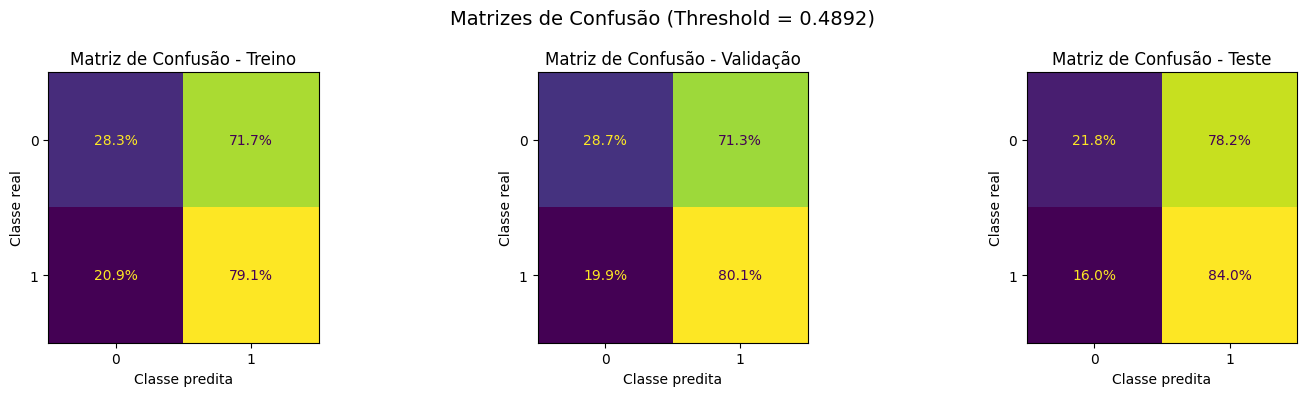

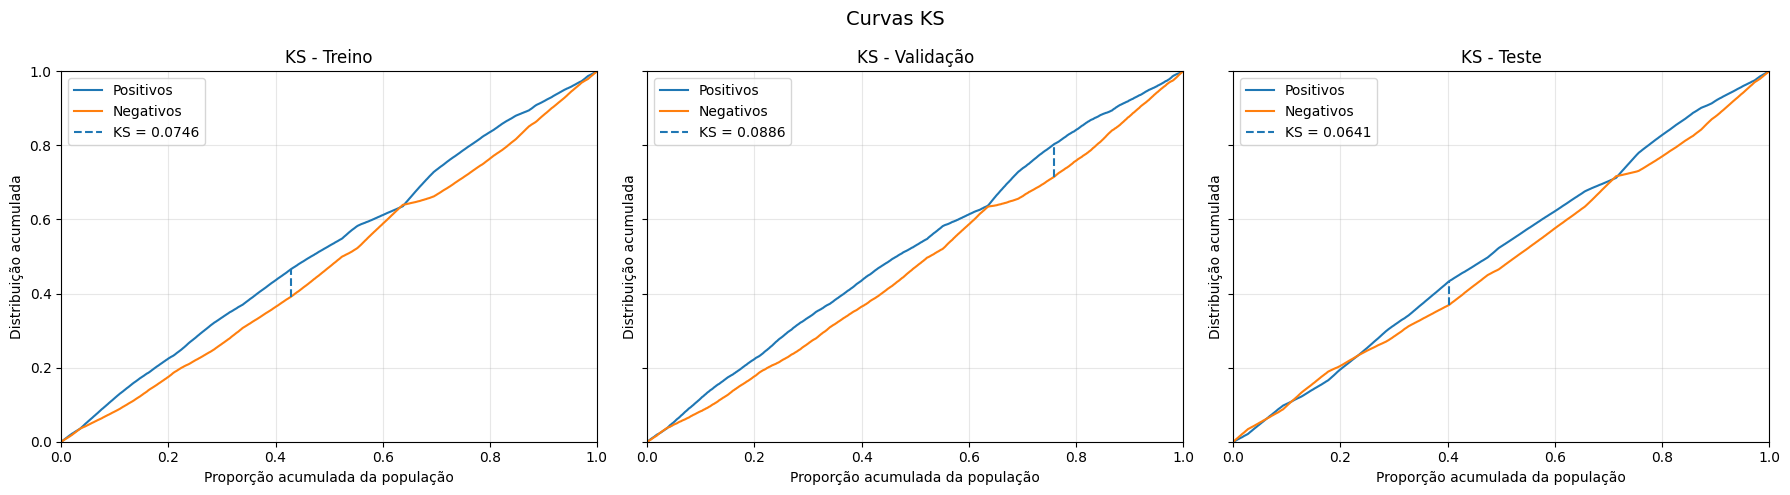

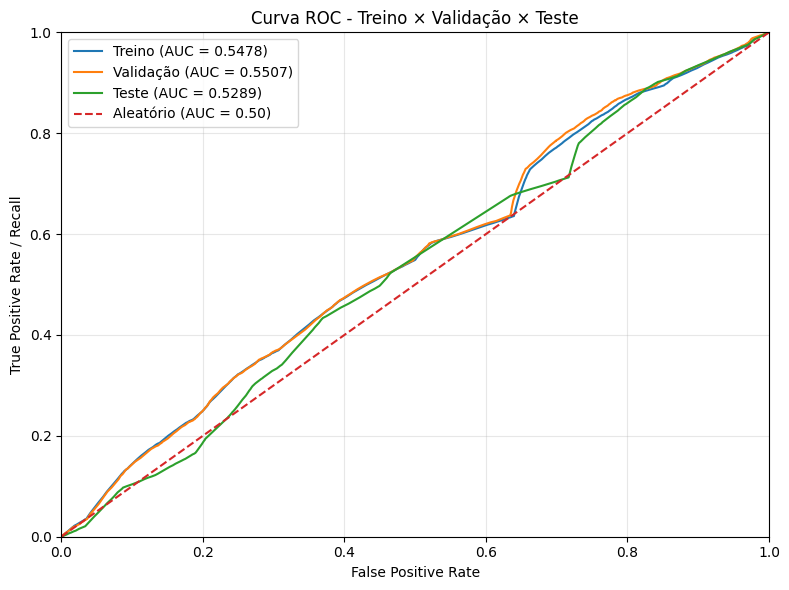

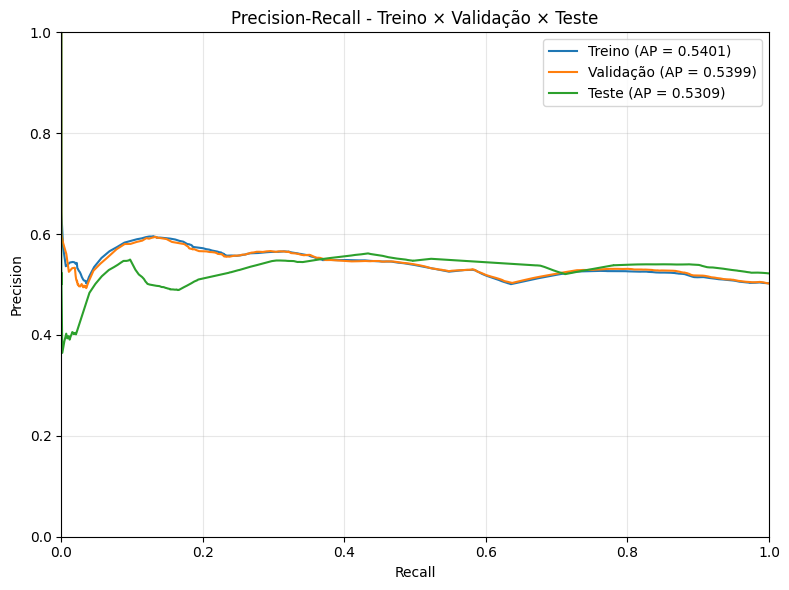

In [11]:
metrics_lr, threshold_lr = evaluate_model(
    model=model_lr,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    threshold="ks"
)

### Decision Tree

In [ ]:
model_dt = Pipeline([
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

model_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['id_escola','sigla_uf','regiao','rede_desc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('frequency', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

Threshold selecionado pelo KS (validação): 0.4929
KS máximo na validação: 0.1892

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision
Dataset,,,,,,
Treino,0.6600,0.5895,0.5985,0.6421,0.1973,0.6420
Validação,0.6724,0.5840,0.5950,0.6326,0.1892,0.6340
Teste,0.5247,0.5922,0.5633,0.5900,0.1303,0.6165


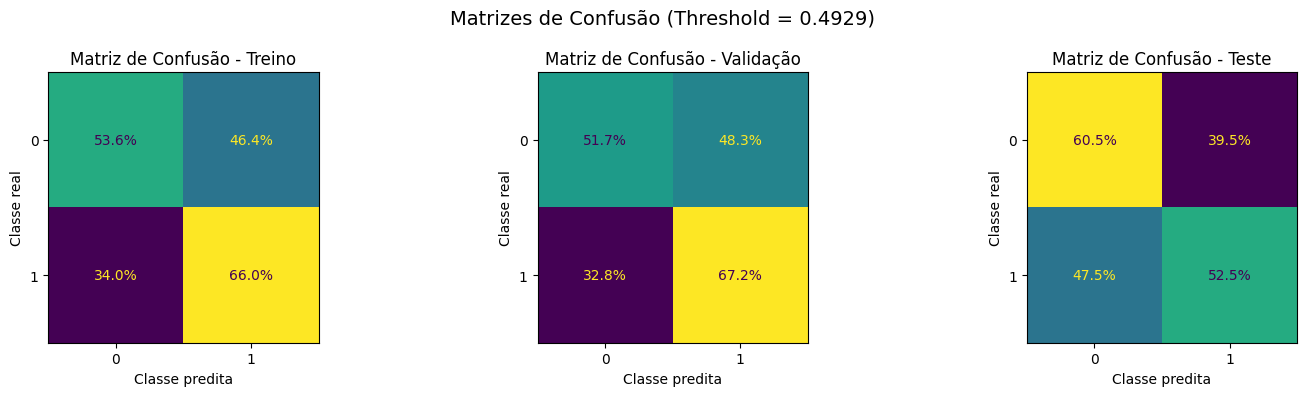

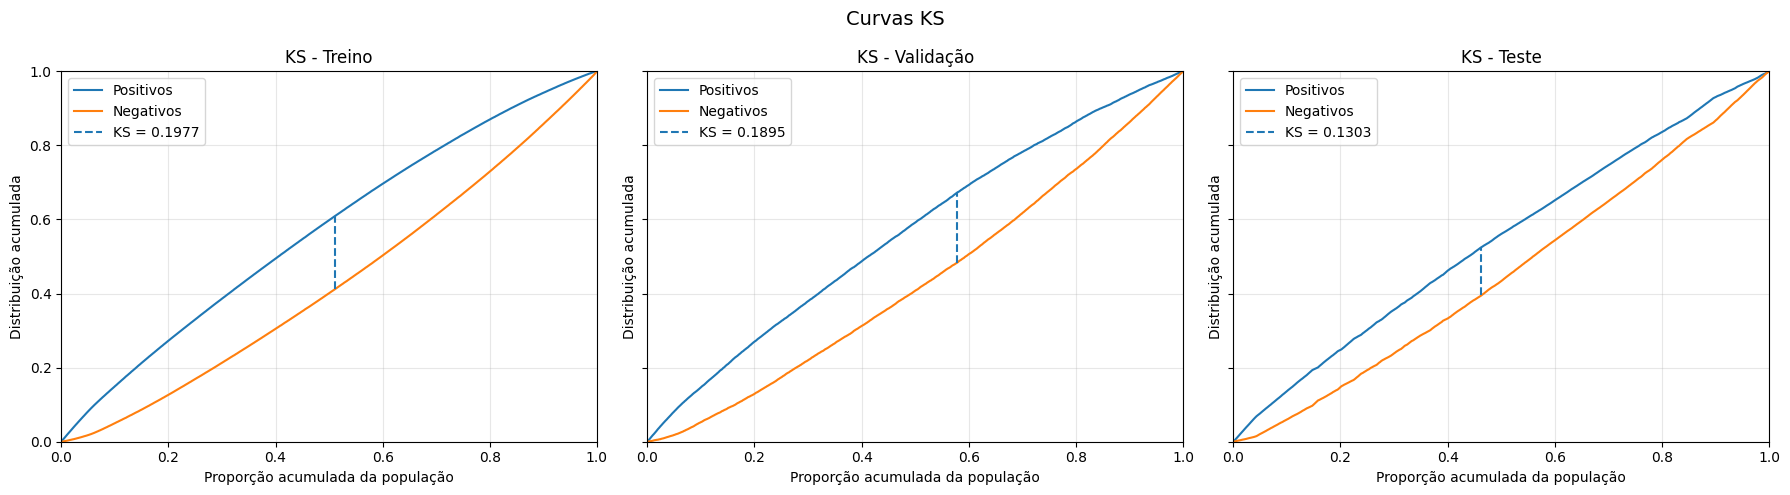

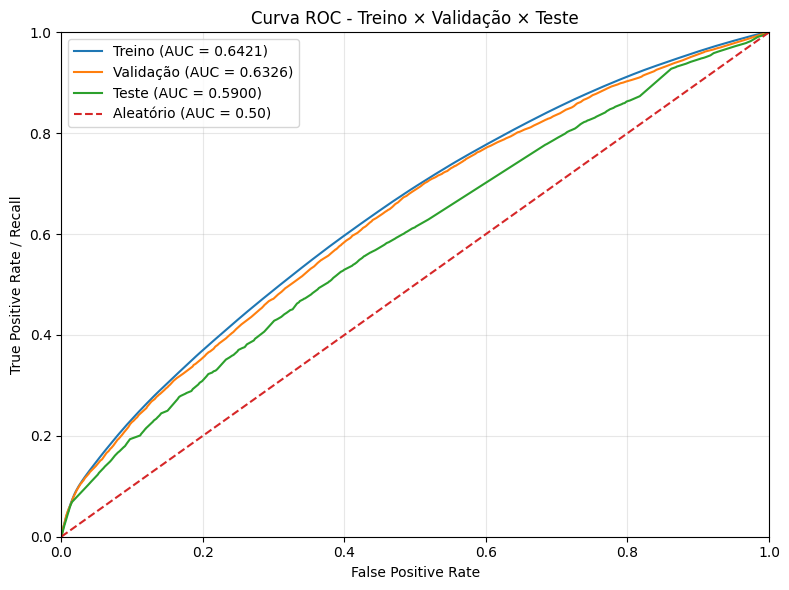

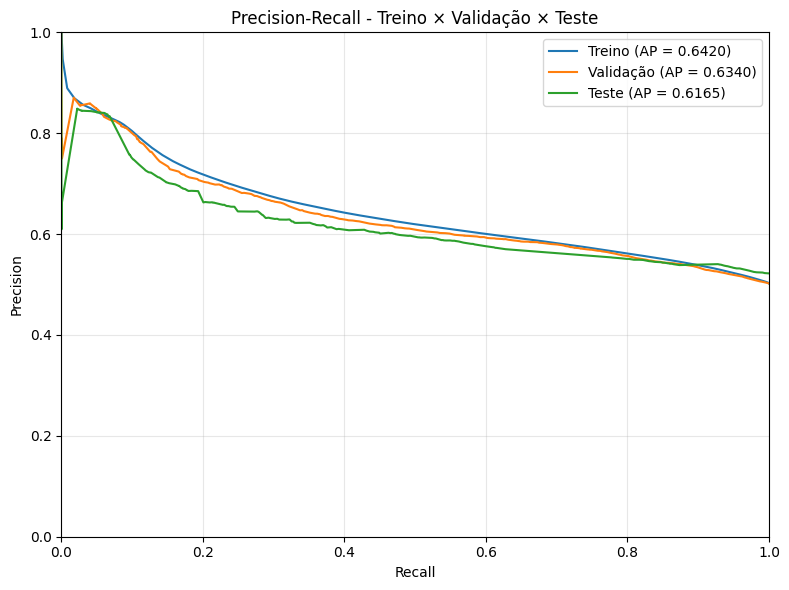

In [13]:
metrics_dt, threshold_dt = evaluate_model(
    model=model_dt,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    threshold="ks"
)

### Random Forest

In [ ]:
model_rf = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

model_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['id_escola','sigla_uf','regiao','rede_desc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('frequency', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

Threshold selecionado pelo KS (validação): 0.4894
KS máximo na validação: 0.1891

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision
Dataset,,,,,,
Treino,0.6613,0.5892,0.5985,0.6421,0.1972,0.6420
Validação,0.6731,0.5838,0.5949,0.6326,0.1891,0.6340
Teste,0.5252,0.5927,0.5637,0.5963,0.1311,0.6190


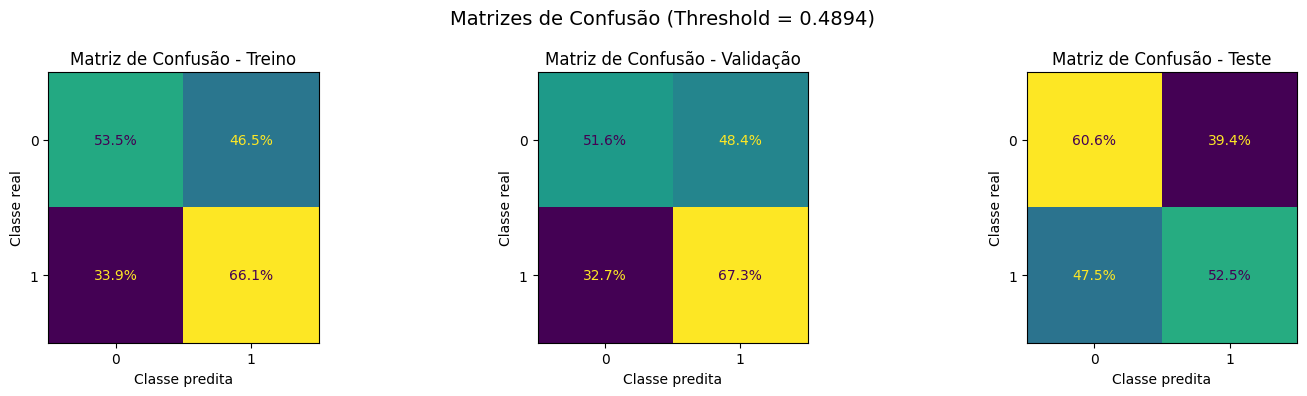

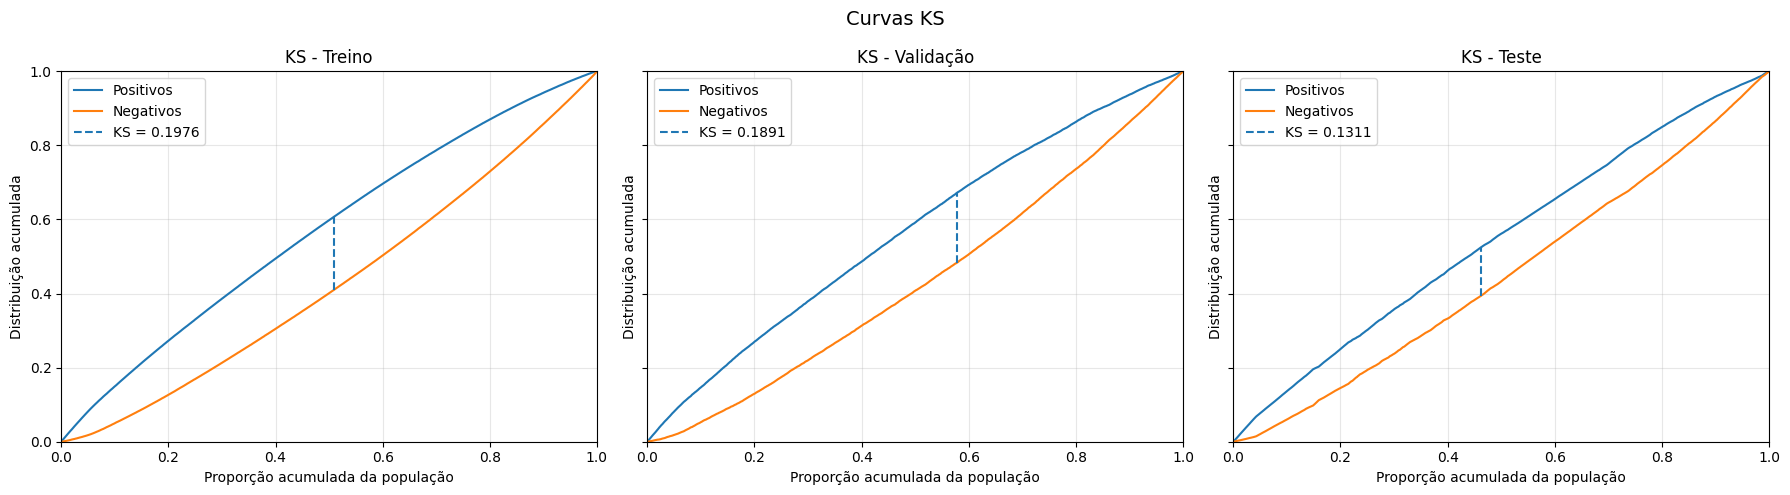

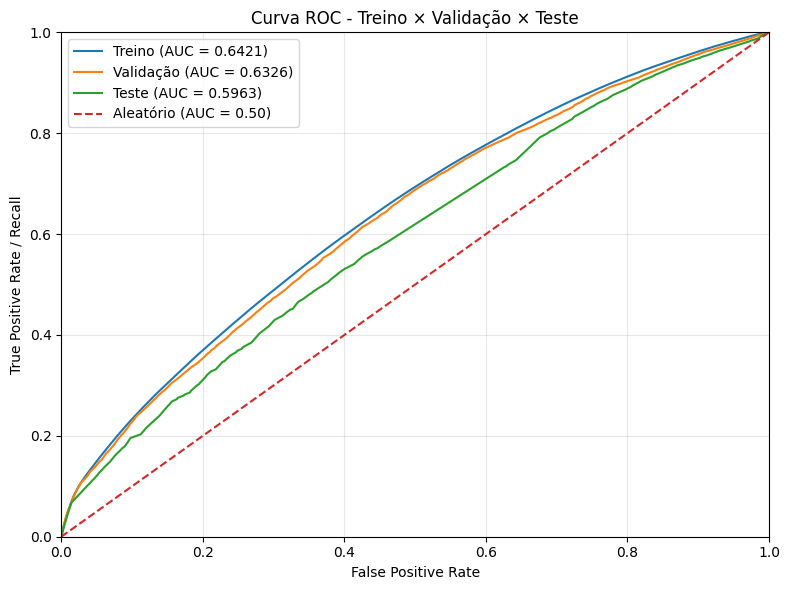

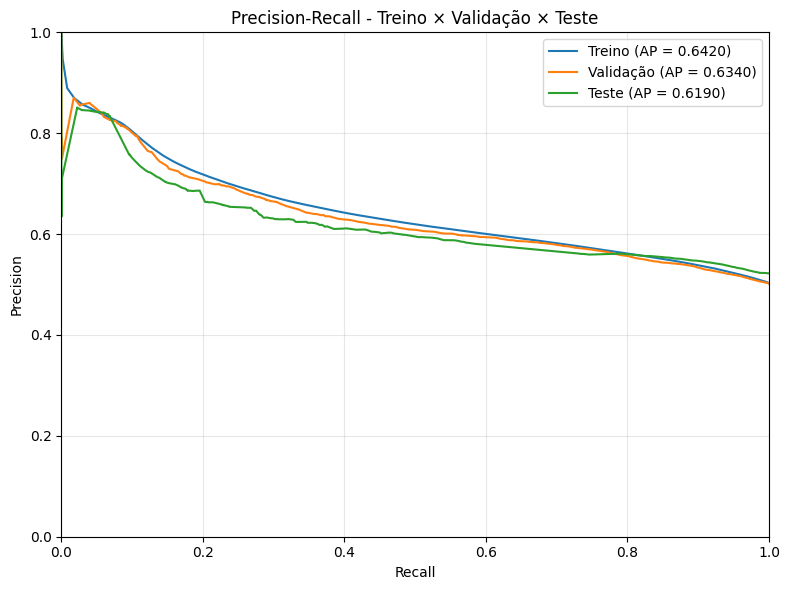

In [15]:
metrics_rf, threshold_rf = evaluate_model(
    model=model_rf,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    threshold="ks"
)

### LightGBM

In [17]:
model_lgbm = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LGBMClassifier(
        random_state=42
    ))
])

model_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 70193, number of negative: 69601
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 72
[LightGBM] [Info] Number of data points in the train set: 139794, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502117 -> initscore=0.008470
[LightGBM] [Info] Start training from score 0.008470


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['id_escola','sigla_uf','regiao','rede_desc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('frequency', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

Threshold selecionado pelo KS (validação): 0.4974
KS máximo na validação: 0.1902

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision
Dataset,,,,,,
Treino,0.6376,0.5917,0.5971,0.6398,0.1943,0.6396
Validação,0.6468,0.5883,0.5953,0.6342,0.1902,0.6353
Teste,0.5022,0.5975,0.5635,0.5953,0.1339,0.6196


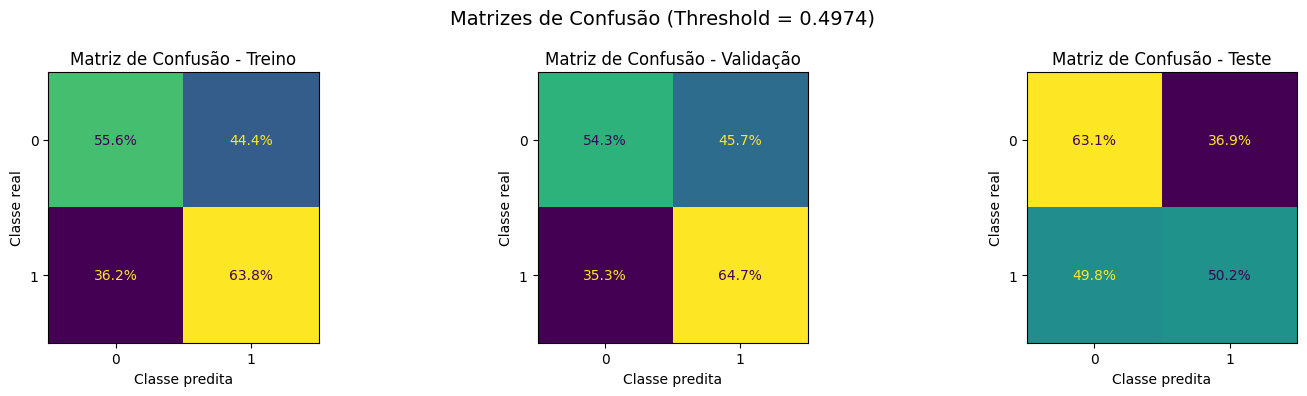

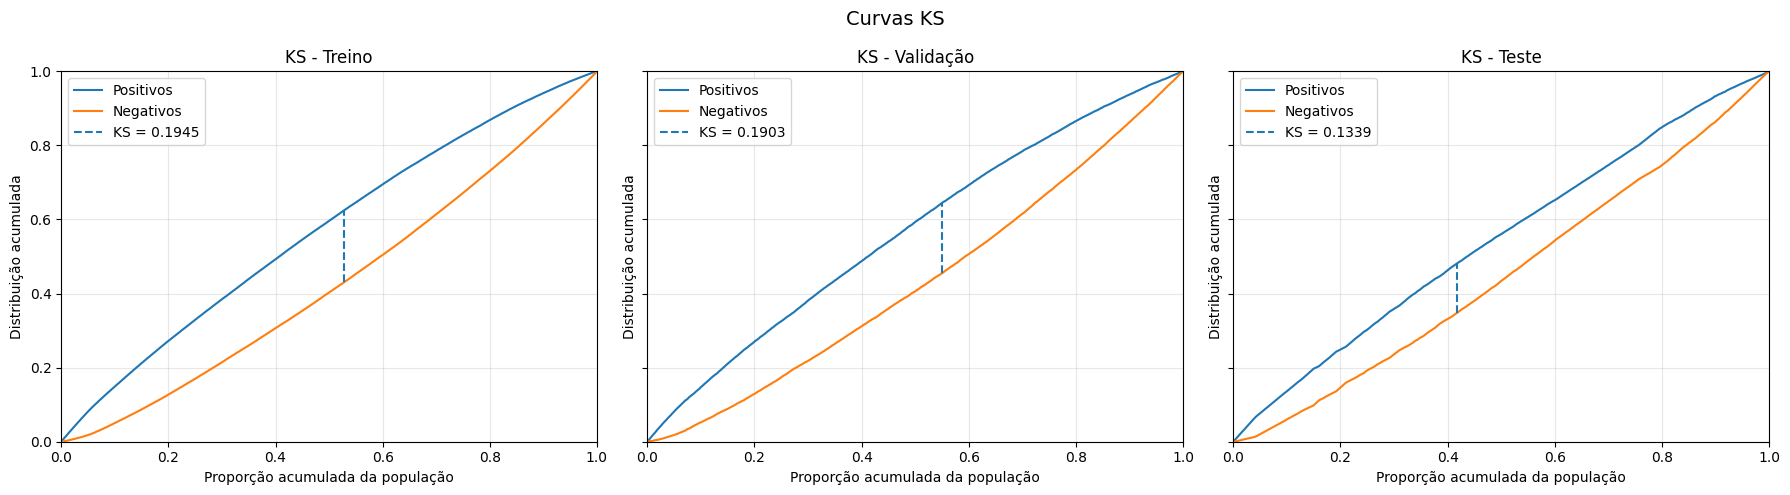

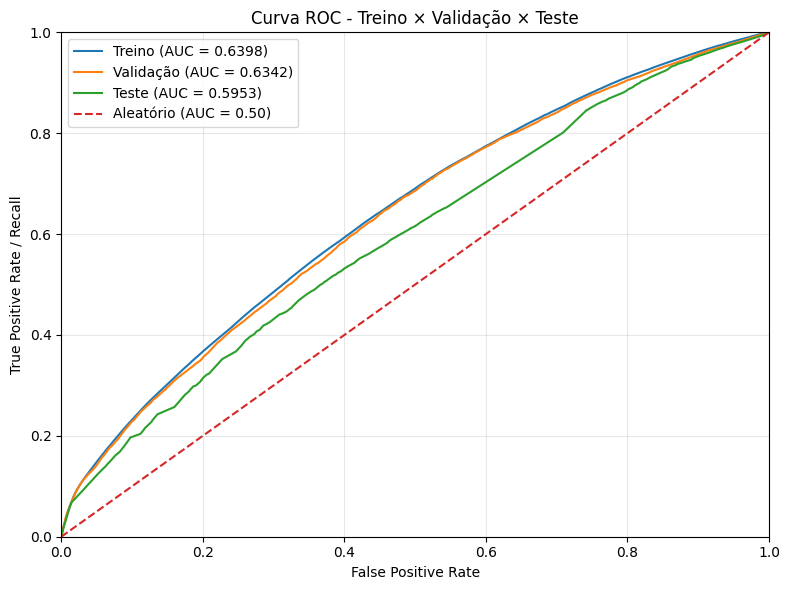

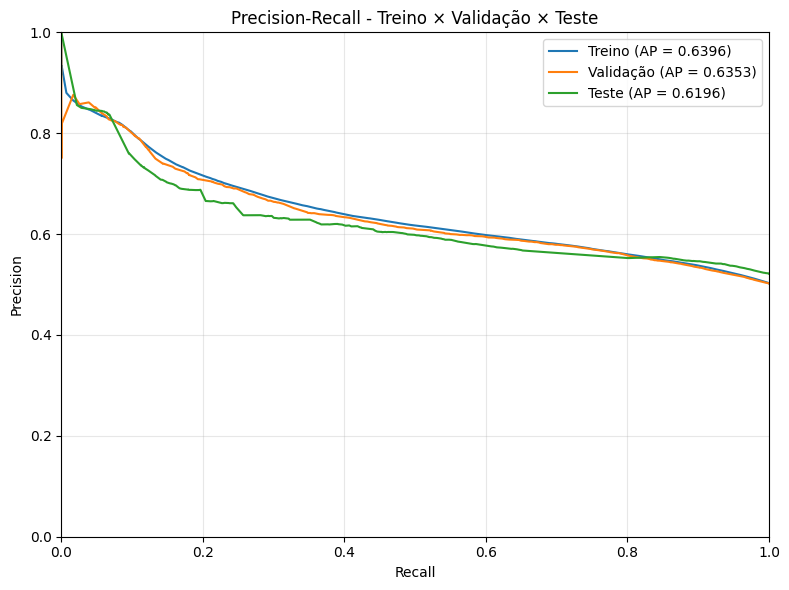

In [18]:
metrics_lgbm, threshold_lgbm = evaluate_model(
    model=model_lgbm,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    threshold="ks"
)

### Naive Bayes

In [19]:
model_nb = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GaussianNB())
])

model_nb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['id_escola','sigla_uf','regiao','rede_desc']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('frequency', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns 

Threshold selecionado pelo KS (validação): 0.4604
KS máximo na validação: 0.0838

Métricas do modelo



,Recall,Precision,Accuracy,AUC,KS,Average Precision
Dataset,,,,,,
Treino,0.8003,0.5261,0.5378,0.5445,0.0733,0.5356
Validação,0.8078,0.5295,0.5430,0.5475,0.0838,0.5363
Teste,0.8510,0.5401,0.5439,0.5315,0.0741,0.5322


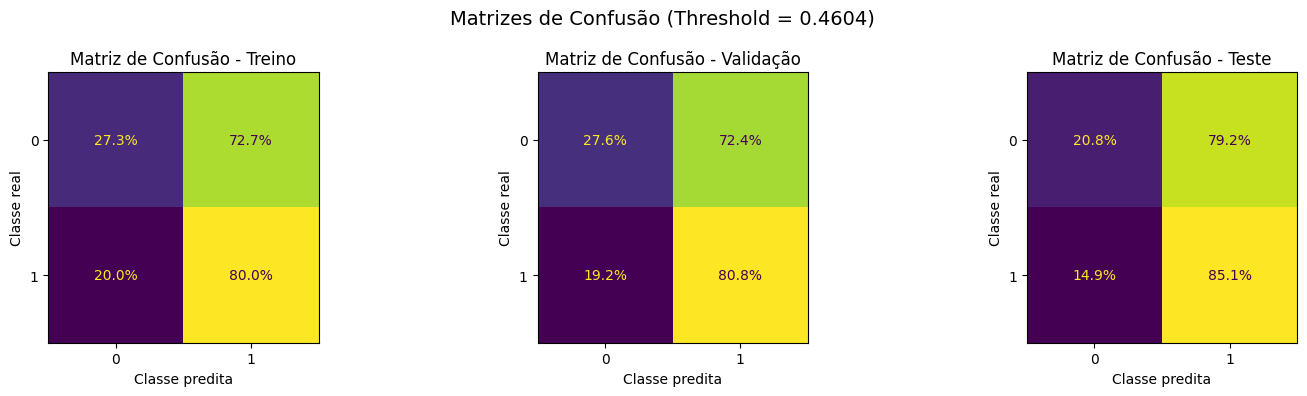

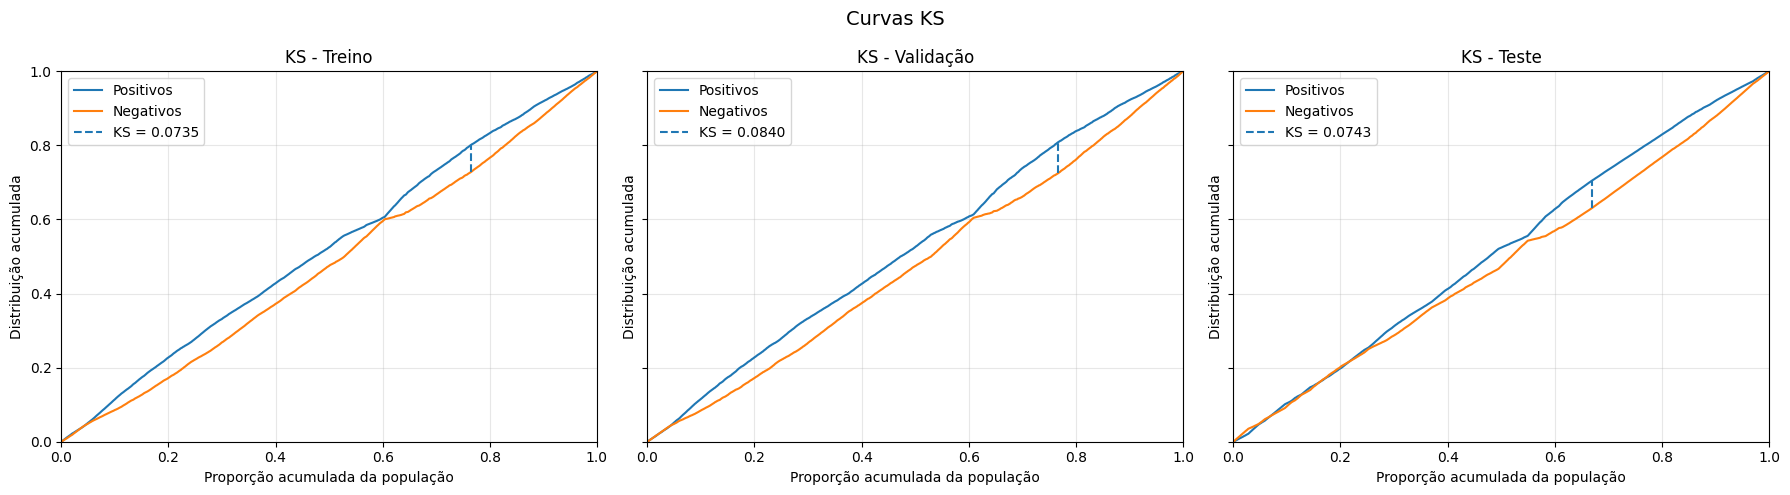

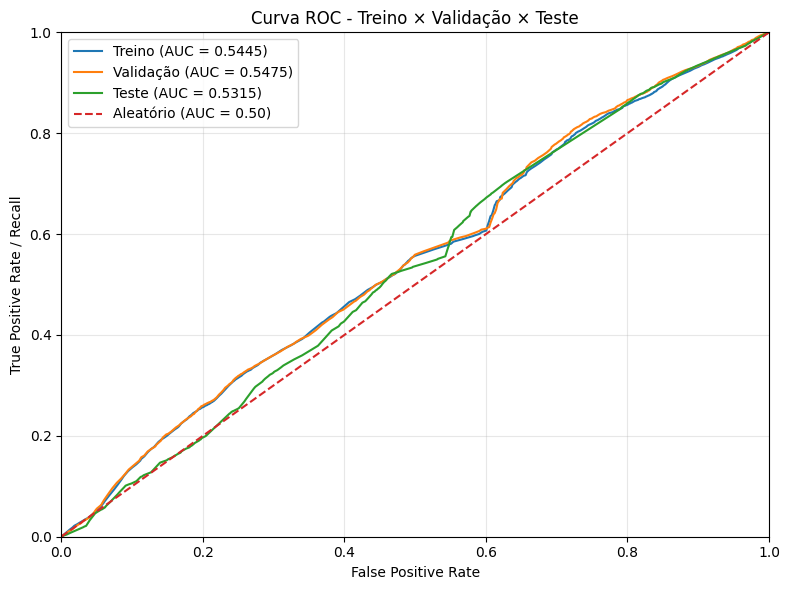

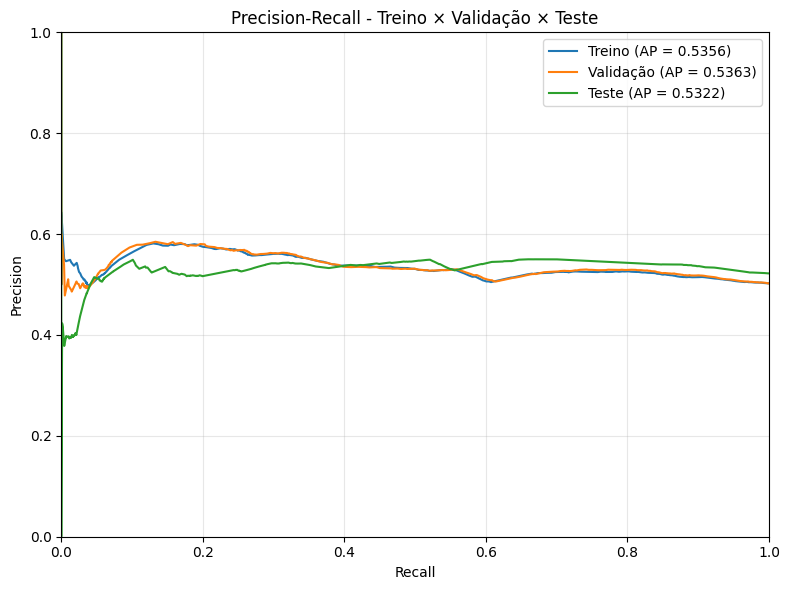

In [20]:
metrics_nb, threshold_nb = evaluate_model(
    model=model_nb,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test,
    threshold="ks"
)